In [0]:
df = spark.table("ecommerce_sales_analysis")

import os
os.makedirs('/dbfs/FileStore', exist_ok=True)

df.toPandas().to_csv("/dbfs/FileStore/ecommerce_sales_analysis.csv", index=False)

In [0]:
pdf["total_sales"] = pdf[[
    "sales_month_1","sales_month_2","sales_month_3",
    "sales_month_4","sales_month_5","sales_month_6"
]].sum(axis=1)

pdf.head()

,product_id,product_name,category,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,sales_month_5,sales_month_6,sales_month_7,sales_month_8,sales_month_9,sales_month_10,sales_month_11,sales_month_12,total_sales
0,1,Product_1,Clothing,190.40,1.7,220,479,449,92,784,604,904,446,603,807,252,695,306,3312
1,2,Product_2,Home & Kitchen,475.60,3.2,903,21,989,861,863,524,128,610,436,176,294,772,353,3386
2,3,Product_3,Toys,367.34,4.5,163,348,558,567,143,771,409,290,828,340,667,267,392,2796
3,4,Product_4,Toys,301.34,3.9,951,725,678,59,15,937,421,670,933,56,157,168,203,2835
4,5,Product_5,Books,82.23,4.2,220,682,451,649,301,620,293,411,258,854,548,770,257,2996


In [0]:
pdf["total_sales"] = pdf[
    ["sales_month_1","sales_month_2","sales_month_3",
     "sales_month_4","sales_month_5","sales_month_6"]
].sum(axis=1)

pdf.head()

,product_id,product_name,category,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,sales_month_5,sales_month_6,sales_month_7,sales_month_8,sales_month_9,sales_month_10,sales_month_11,sales_month_12,total_sales
0,1,Product_1,Clothing,190.40,1.7,220,479,449,92,784,604,904,446,603,807,252,695,306,3312
1,2,Product_2,Home & Kitchen,475.60,3.2,903,21,989,861,863,524,128,610,436,176,294,772,353,3386
2,3,Product_3,Toys,367.34,4.5,163,348,558,567,143,771,409,290,828,340,667,267,392,2796
3,4,Product_4,Toys,301.34,3.9,951,725,678,59,15,937,421,670,933,56,157,168,203,2835
4,5,Product_5,Books,82.23,4.2,220,682,451,649,301,620,293,411,258,854,548,770,257,2996


In [0]:
top_products = pdf.sort_values(by="total_sales", ascending=False).head(10)

top_products[["product_name","total_sales"]]

,product_name,total_sales
904,Product_905,5341
923,Product_924,4988
830,Product_831,4906
849,Product_850,4849
195,Product_196,4827
228,Product_229,4819
112,Product_113,4758
477,Product_478,4678
542,Product_543,4656
501,Product_502,4633


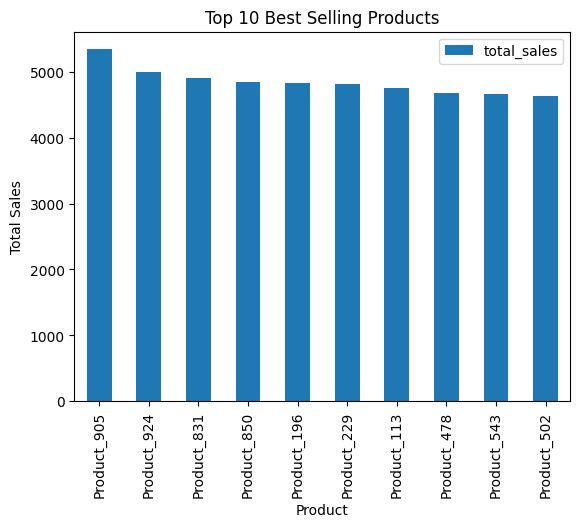

In [0]:
import matplotlib.pyplot as plt

top_products.plot(
    x="product_name",
    y="total_sales",
    kind="bar"
)

plt.title("Top 10 Best Selling Products")
plt.ylabel("Total Sales")
plt.xlabel("Product")
plt.show()

In [0]:
category_sales = pdf.groupby("category")["total_sales"].sum().reset_index()

category_sales

,category,total_sales
0,Books,465403
1,Clothing,400527
2,Electronics,434914
3,Health,408707
4,Home & Kitchen,366086
5,Sports,458485
6,Toys,461254


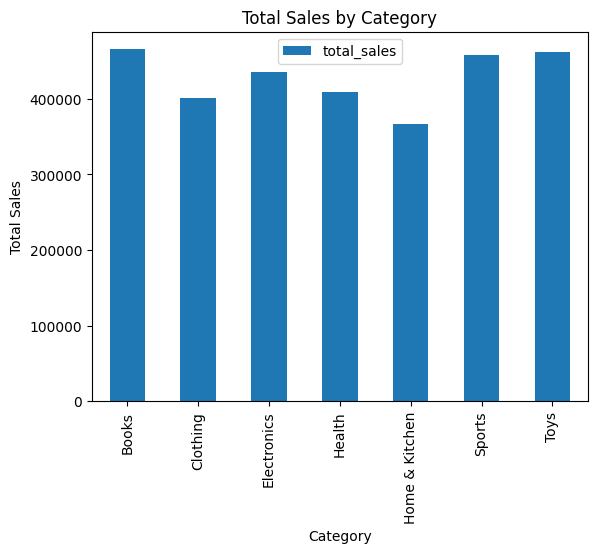

In [0]:
import matplotlib.pyplot as plt

category_sales.plot(
    x="category",
    y="total_sales",
    kind="bar"
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

In [0]:
monthly_sales = pdf[
    ["sales_month_1","sales_month_2","sales_month_3",
     "sales_month_4","sales_month_5","sales_month_6"]
].sum()

monthly_sales

sales_month_1    498306
sales_month_2    507661
sales_month_3    506739
sales_month_4    503823
sales_month_5    487194
sales_month_6    491653
dtype: int64

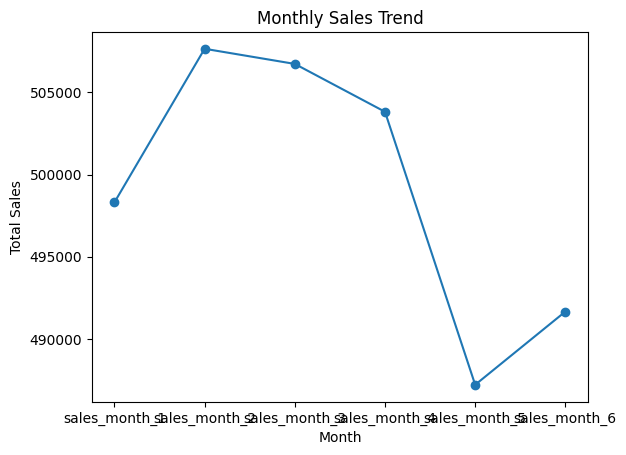

In [0]:
monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

In [0]:
%pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
numeric_data = pdf[
    ["price","review_score","review_count",
     "sales_month_1","sales_month_2","sales_month_3",
     "sales_month_4","sales_month_5","sales_month_6",
     "total_sales"]
]

In [0]:
correlation = numeric_data.corr()

correlation

,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,sales_month_5,sales_month_6,total_sales
price,1.000000,0.028960,0.042189,-0.033860,-0.002978,-0.023203,0.044579,0.030024,-0.051430,-0.014968
review_score,0.028960,1.000000,0.027351,0.023949,-0.076709,-0.012420,-0.016875,-0.038930,0.017519,-0.040507
review_count,0.042189,0.027351,1.000000,-0.019286,-0.036431,-0.029381,-0.021719,-0.013798,-0.006579,-0.050254
sales_month_1,-0.033860,0.023949,-0.019286,1.000000,0.051889,0.006204,0.048705,0.016276,0.036269,0.459118
sales_month_2,-0.002978,-0.076709,-0.036431,0.051889,1.000000,-0.012759,-0.100955,0.056114,0.035142,0.402946
sales_month_3,-0.023203,-0.012420,-0.029381,0.006204,-0.012759,1.000000,-0.011394,-0.009051,0.018806,0.398932
sales_month_4,0.044579,-0.016875,-0.021719,0.048705,-0.100955,-0.011394,1.000000,-0.016243,0.046118,0.379076
sales_month_5,0.030024,-0.038930,-0.013798,0.016276,0.056114,-0.009051,-0.016243,1.000000,0.036992,0.426644
sales_month_6,-0.051430,0.017519,-0.006579,0.036269,0.035142,0.018806,0.046118,0.036992,1.000000,0.463844
total_sales,-0.014968,-0.040507,-0.050254,0.459118,0.402946,0.398932,0.379076,0.426644,0.463844,1.000000


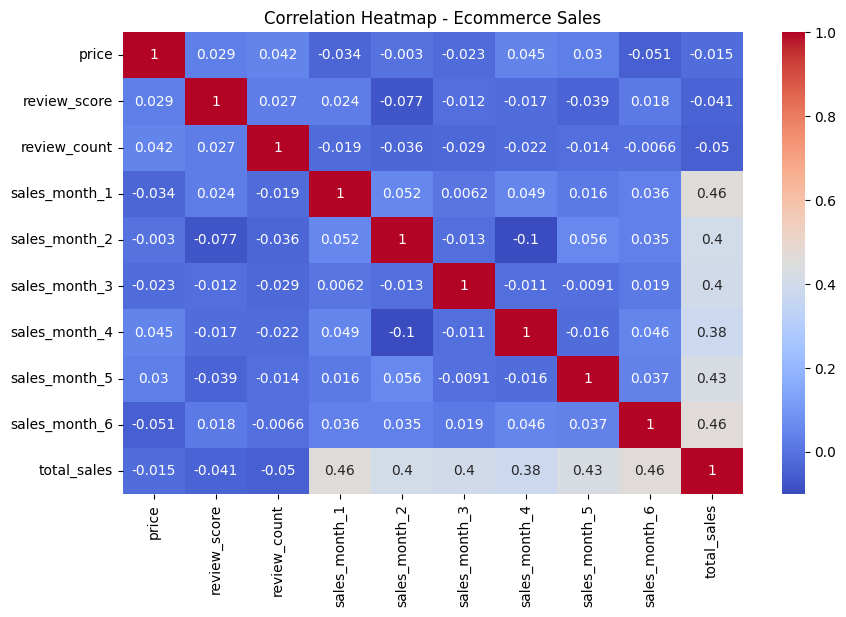

In [0]:
plt.figure(figsize=(10,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap - Ecommerce Sales")
plt.show()

In [0]:
top_rated = pdf.sort_values(by="review_score", ascending=False).head(10)

top_rated[["product_name","review_score","total_sales"]]

,product_name,review_score,total_sales
11,Product_12,5.0,3256
333,Product_334,5.0,2583
715,Product_716,5.0,3712
616,Product_617,5.0,3021
727,Product_728,5.0,2086
88,Product_89,5.0,2642
54,Product_55,5.0,3573
464,Product_465,5.0,2302
954,Product_955,5.0,1136
889,Product_890,5.0,2257


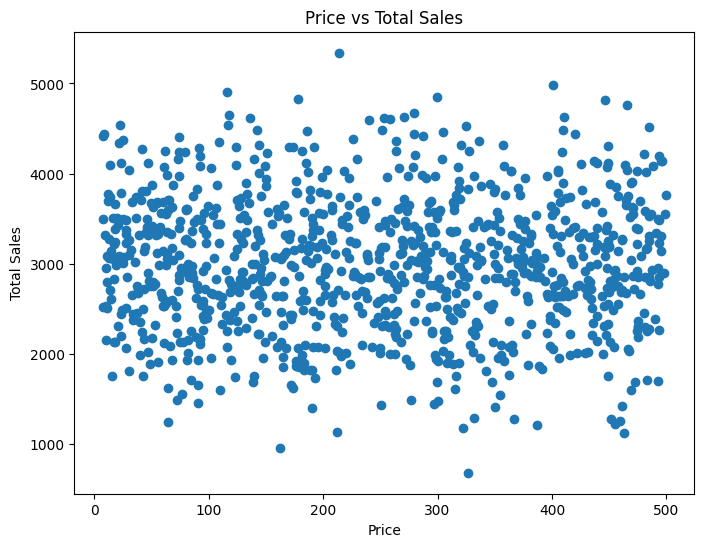

In [0]:
plt.figure(figsize=(8,6))

plt.scatter(pdf["price"], pdf["total_sales"])

plt.title("Price vs Total Sales")
plt.xlabel("Price")
plt.ylabel("Total Sales")

plt.show()

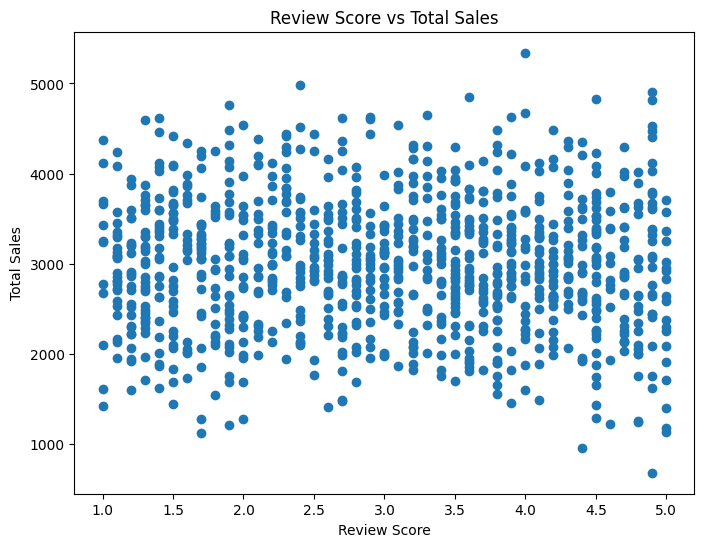

In [0]:
plt.figure(figsize=(8,6))

plt.scatter(pdf["review_score"], pdf["total_sales"])

plt.title("Review Score vs Total Sales")
plt.xlabel("Review Score")
plt.ylabel("Total Sales")

plt.show()